# **SINTONIZACIÓN DE UN CONTROLADOR PID MEDIANTE PSO**

El controlador calcula una señal de control $u(t)$ basada en el error entre la salida deseada $y_{ref}(t) - y(t)$

La señal de control es:
$$u(t) = K_pe(t) + K_i \int_{0}^{t} e(\tau)dτ + K_d  \frac{de(T)}{dt}$$

Donde: \
• $K_p$: Ganancia proporcional, ajusta la reacción inmediata al error. \
• $K_i$: Ganancia integral, elimina el error en estado estacionario. \
• $K_d$: Ganancia derivativa, suaviza la respuesta y anticipa cambios.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
def ISE_PID(pos):
    Kp = pos[0]
    Ki = pos[1]
    Kd = pos[2]

    dt = 0.01
    tiempo = np.arange(0, 10, dt)

    y = 0.0
    e_prev = 0
    integral = 0
    ISE = 0

    for t in tiempo:
        e = 1 - y
        integral += e * dt
        integral = np.clip(integral, -5, 5)

        derivada = (e - e_prev) / dt
        u = Kp*e + Ki*integral + Kd*derivada

        u = np.clip(u, -10, 10)
        e_prev = e

        y = y + dt * (-y + u)
        ISE += e**2 * dt

    return ISE

def inicializar_particulas(n_particulas, dim, limites):
    posiciones = np.zeros((n_particulas, dim))
    velocidades = np.zeros((n_particulas, dim))

    for i in range(n_particulas):
        for d in range(dim):
            posiciones[i][d] = np.random.uniform(limites[d][0], limites[d][1])
            velocidades[i][d] = np.random.uniform(
                -abs(limites[d][1] - limites[d][0]),
                 abs(limites[d][1] - limites[d][0])
            )

    return posiciones, velocidades

def evaluar_PID(pos):
    Kp, Ki, Kd = pos

    dt = 0.01
    tiempo = np.arange(0, 10, dt)

    y = 0.0
    e_prev = 0
    integral = 0

    ISE = 0
    y_hist = []
    u_hist = []

    for t in tiempo:
        e = 1 - y
        integral += e * dt
        integral = np.clip(integral, -5, 5)

        derivada = (e - e_prev) / dt

        u = Kp*e + Ki*integral + Kd*derivada
        u = np.clip(u, -10, 10)
        e_prev = e

        y = y + dt * (-y + u)

        ISE += e**2 * dt
        y_hist.append(y)
        u_hist.append(u)

    y = np.array(y_hist)

    error_final = abs(1 - y[-1])

    tolerancia = 0.02
    indices = np.where((y > 1 - tolerancia) & (y < 1 + tolerancia))[0]
    t_settle = tiempo[indices[0]] if len(indices) > 0 else np.inf

    return {
        "ISE": ISE,
        "error_final": error_final,
        "y_max": np.max(y),
        "y_final": y[-1]
    }


dim = 3
n_particulas = 50
max_iter = 200
w = 0.7
c1 = 1.5
c2 = 1.5

limites = [(0, 7), (0, 3), (0, 1.5)]

# Inicialización
posiciones, velocidades = inicializar_particulas(n_particulas, dim, limites)
pbest_pos = np.copy(posiciones)
pbest_val = np.zeros(n_particulas)

for i in range(n_particulas):
    pbest_val[i] = ISE_PID(posiciones[i])

gbest_indice = np.argmin(pbest_val)
gbest_pos = np.copy(pbest_pos[gbest_indice])
gbest_val = pbest_val[gbest_indice]

# Límite de velocidad por dimensión
v_max = np.zeros((dim))
for d in range(dim):
    v_max[d] = 0.2 * (limites[d][1] - limites[d][0])

for t in range(max_iter):
    for i in range(n_particulas):
        r1 = np.random.random()
        r2 = np.random.random()

        for d in range(dim):
            cognitivo = c1 * r1 * (pbest_pos[i][d] - posiciones[i][d])
            social = c2 * r2 * (gbest_pos[d] - posiciones[i][d])

            velocidades[i][d] = w * velocidades[i][d] + cognitivo + social
            velocidades[i][d] = np.clip(velocidades[i][d], -v_max[d], v_max[d])

        for d in range(dim):
            posiciones[i][d] = posiciones[i][d] + velocidades[i][d]
            posiciones[i][d] = np.clip(posiciones[i][d], limites[d][0], limites[d][1])

        fitness = ISE_PID(posiciones[i])

        if fitness < pbest_val[i]:
            pbest_val[i] = fitness
            pbest_pos[i] = np.copy(posiciones[i])

        if fitness < gbest_val:
            gbest_val = fitness
            gbest_pos = np.copy(posiciones[i])

res = evaluar_PID(gbest_pos)


print("Minimo encontrado:")
print("Kp =", gbest_pos[0])
print("Ki =", gbest_pos[1])
print("Kd =", gbest_pos[2])

print("ISE =", res["ISE"])
print("Error final =", res["error_final"])
print("Valor final de y =", res["y_final"])

Minimo encontrado:
Kp = 7.0
Ki = 4.0
Kd = 0.029600000000000255
ISE = 0.07830179396087257
Error final = 0.0003172936843576224
Valor final de y = 0.9996827063156424


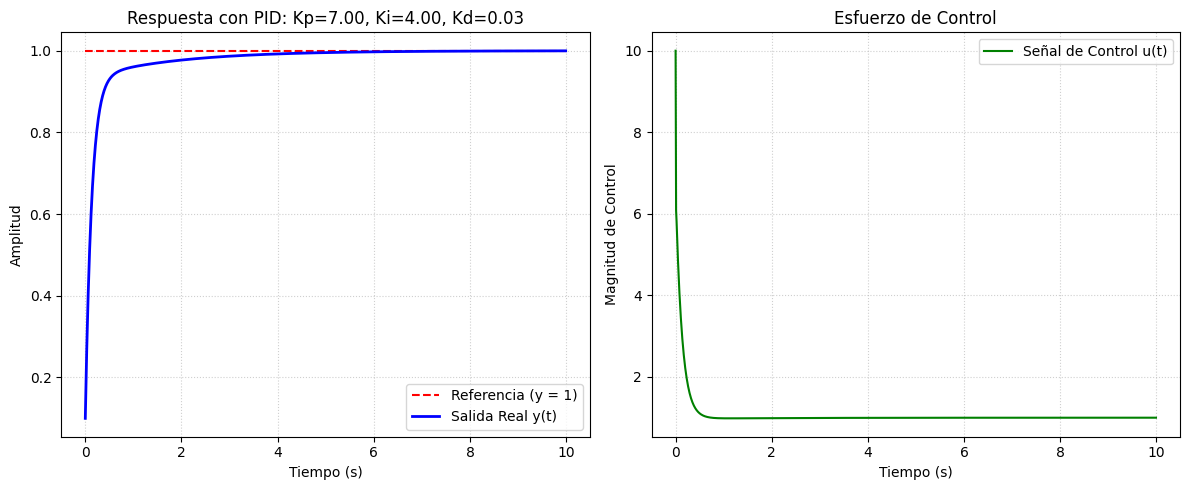

In [ ]:
Kp_opt, Ki_opt, Kd_opt = gbest_pos

dt = 0.01
tiempo = np.arange(0, 10, dt)
referencia = np.ones_like(tiempo)

y = 0.0
e_prev = 0
integral = 0

y_hist = []
u_hist = []

for t in tiempo:
    e = 1 - y

    integral += e * dt
    integral = np.clip(integral, -5, 5)

    derivada = (e - e_prev) / dt

    u = Kp_opt*e + Ki_opt*integral + Kd_opt*derivada
    u = np.clip(u, -10, 10)

    e_prev = e

    y = y + dt * (-y + u)

    y_hist.append(y)
    u_hist.append(u)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tiempo, referencia, 'r--', label='Referencia (y = 1)')
plt.plot(tiempo, y_hist, 'b-', linewidth=2, label='Salida Real y(t)')
plt.title(f'Respuesta con PID: Kp={Kp_opt:.2f}, Ki={Ki_opt:.2f}, Kd={Kd_opt:.2f}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tiempo, u_hist, 'g-', label='Señal de Control u(t)')
plt.title('Esfuerzo de Control')
plt.xlabel('Tiempo (s)')
plt.ylabel('Magnitud de Control')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()